# SP(k) Unit-Consistent Check (k in h/Mpc)

This notebook is a minimal, unit-consistent validation of SP(k) suppression.

It compares:
- `S_ccl(k, z)` from `BaryonsSPK.boost_factor`
- `S_pyspk(k, z)` from direct `pyspk`

> Focus: `k` is defined directly in **h/Mpc** and spans up to `12 h/Mpc`.

> Note: `BaryonsSPK` in CCL accepts `k` in `Mpc^-1`, so we convert with
`k_mpc = h * k_hmpc` before calling `boost_factor`.

In [1]:
from pathlib import Path

from typing import Literal

import numpy as np
import pyccl as ccl

try:
    import pyspk
except ImportError as err:
    raise ImportError(
        "This notebook requires pyspk. Install with: pip install pyspk"
    ) from err

import matplotlib.pyplot as plt

In [2]:
# Configuration (explicit k grid in h/Mpc)
SO = 200
relation_kind: Literal["power_law"] = "power_law"

fb_a = 0.5
fb_pow = 0.3
fb_pivot = 10**13.5

k_min_hmpc = 0.01
k_max_hmpc = 12.0
n_k = 400

# Requested grid and redshifts for comparison
k_hmpc = np.geomspace(k_min_hmpc, k_max_hmpc, n_k)
z_arr = np.array([0.0, 1.0, 3.0])
a_arr = 1.0 / (1.0 + z_arr)

# Build a reference cosmology only to get h and E(z) when needed
cosmo = ccl.CosmologyVanillaLCDM(transfer_function="bbks")
h = float(cosmo["h"]) # type: ignore
k_mpc = k_hmpc * h

print("Configured relation:", relation_kind)
print(f"h = {h:.3f}")
print(f"k range [h/Mpc]: {k_hmpc.min():.3e} -> {k_hmpc.max():.3e}")
print(f"k range [Mpc^-1]: {k_mpc.min():.3e} -> {k_mpc.max():.3e}")
print("Redshifts:", z_arr)

Configured relation: power_law
h = 0.670
k range [h/Mpc]: 1.000e-02 -> 1.200e+01
k range [Mpc^-1]: 6.700e-03 -> 8.040e+00
Redshifts: [0. 1. 3.]


In [3]:
# CCL SP(k) suppression from BaryonsSPK (primary path)
bar_spk = ccl.BaryonsSPK(
    SO=SO,
    relation_kind=relation_kind,
    k_min_hmpc=k_min_hmpc,
    k_max_hmpc=k_max_hmpc,
    n_k=n_k,
    out_of_bounds_policy="error",
    fb_a=fb_a,
    fb_pow=fb_pow,
    fb_pivot=fb_pivot,
)

S_ccl = np.vstack([bar_spk.boost_factor(cosmo, k_mpc, a_val) for a_val in a_arr])
print("Computed S_ccl from BaryonsSPK.boost_factor on converted k_mpc grid.")

Computed S_ccl from BaryonsSPK.boost_factor on converted k_mpc grid.


/Users/jaimesalcido/CCL/pyccl/baryons/spk.py:272: UserWarning: Scales with k_max > k_ny = 8.0 [h/Mpc] may not be accurately reproduced by the model.
  return pyspk.build_sup_model_evaluator(
/Users/jaimesalcido/CCL/pyccl/baryons/spk.py:272: UserWarning: Scales with k_max > k_ny = 8.0 [h/Mpc] may not be accurately reproduced by the model.
  return pyspk.build_sup_model_evaluator(
/Users/jaimesalcido/CCL/pyccl/baryons/spk.py:272: UserWarning: Scales with k_max > k_ny = 8.0 [h/Mpc] may not be accurately reproduced by the model.
  return pyspk.build_sup_model_evaluator(


In [4]:
# Direct pyspk suppression on the same k_hmpc grid
evaluator = pyspk.build_sup_model_evaluator(
    SO=SO,
    relation_kind=relation_kind,
    k_array=k_hmpc,
)

S_pyspk = np.empty_like(S_ccl)
for i, z_val in enumerate(z_arr):
    _, sup = evaluator(
        z=float(z_val),
        fb_a=fb_a,
        fb_pow=fb_pow,
        fb_pivot=fb_pivot,
    )
    S_pyspk[i, :] = sup

finite_mask = np.isfinite(S_ccl) & np.isfinite(S_pyspk)
abs_diff = np.abs(S_ccl - S_pyspk)
rel_diff = abs_diff / np.maximum(np.abs(S_pyspk), 1.0e-12)

print("Agreement summary (BaryonsSPK boost vs direct pyspk):")
for i, z_val in enumerate(z_arr):
    this_valid = finite_mask[i]
    if not np.any(this_valid):
        print(f"z={z_val:.1f}  no finite comparison points")
        continue
    print(
        f"z={z_val:.1f}  max|ΔS|={np.max(abs_diff[i, this_valid]):.3e}  "
        f"max rel|ΔS|={np.max(rel_diff[i, this_valid]):.3e}"
    )
    if np.any(~this_valid):
        invalid_k = k_hmpc[~this_valid]
        print(
            f"  non-finite region in k_hmpc: "
            f"[{invalid_k.min():.3f}, {invalid_k.max():.3f}]"
        )

np.testing.assert_allclose(
    S_ccl[finite_mask],
    S_pyspk[finite_mask],
    rtol=1.0e-6,
    atol=1.0e-8,
)
print("PASS: finite-point agreement at tight tolerance")

Agreement summary (BaryonsSPK boost vs direct pyspk):
z=0.0  max|ΔS|=1.110e-16  max rel|ΔS|=1.256e-16
z=1.0  max|ΔS|=1.110e-16  max rel|ΔS|=1.260e-16
z=3.0  max|ΔS|=2.220e-16  max rel|ΔS|=2.520e-16
  non-finite region in k_hmpc: [10.980, 12.000]
PASS: finite-point agreement at tight tolerance


/var/folders/mm/97jkmxws1v5381f7n2hfm_9w0000gn/T/ipykernel_1740/1421934153.py:2: UserWarning: Scales with k_max > k_ny = 8.0 [h/Mpc] may not be accurately reproduced by the model.
  evaluator = pyspk.build_sup_model_evaluator(
/var/folders/mm/97jkmxws1v5381f7n2hfm_9w0000gn/T/ipykernel_1740/1421934153.py:10: UserWarning: pyspk was calibrated down to z = 0.125. Redshifts z < 0.125 may not be accurately reproduced by the model.
  _, sup = evaluator(


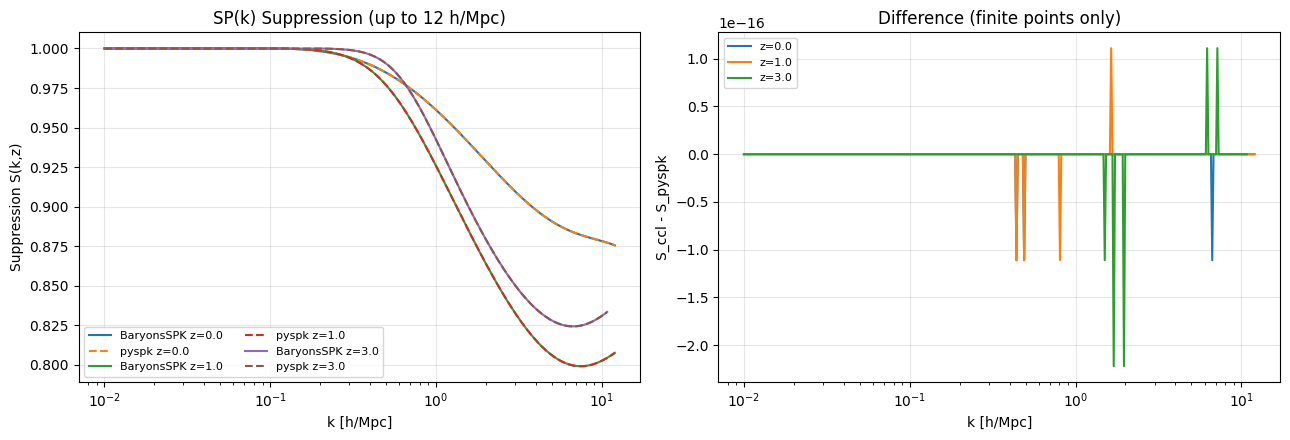

In [5]:
# Plot suppression and finite-point difference vs k_hmpc
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, z_val in enumerate(z_arr):
    axes[0].plot(k_hmpc, S_ccl[i, :], label=f"BaryonsSPK z={z_val:.1f}")
    axes[0].plot(k_hmpc, S_pyspk[i, :], "--", lw=1.5,
                 label=f"pyspk z={z_val:.1f}")

axes[0].set_xscale("log")
axes[0].set_xlabel("k [h/Mpc]")
axes[0].set_ylabel("Suppression S(k,z)")
axes[0].set_title("SP(k) Suppression (up to 12 h/Mpc)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

for i, z_val in enumerate(z_arr):
    valid = finite_mask[i]
    axes[1].plot(
        k_hmpc[valid],
        (S_ccl[i, :] - S_pyspk[i, :])[valid],
        label=f"z={z_val:.1f}",
    )

axes[1].set_xscale("log")
axes[1].set_xlabel("k [h/Mpc]")
axes[1].set_ylabel("S_ccl - S_pyspk")
axes[1].set_title("Difference (finite points only)")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [6]:
# Save arrays for downstream use
out_path = Path("examples/spk_notebook_compare.npz")
out_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    out_path,
    k_hmpc=k_hmpc,
    k_mpc=k_mpc,
    z_arr=z_arr,
    a_arr=a_arr,
    S_ccl=S_ccl,
    S_pyspk=S_pyspk,
    finite_mask=finite_mask,
    abs_diff=abs_diff,
    rel_diff=rel_diff,
)
print(f"Saved: {out_path}")

Saved: examples/spk_notebook_compare.npz
